**This implementation will use matplotlib and numpy to visualize what a matrix actually does to any given vector**

The insipiration for this small project is 3B1B's youtube series on linear algebra which really helped me understand matrices as linear transformations, and I wanted to recreate the animation effect in their video to the best of my ability

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation #If I ever get to animating the transformation, I included the package!

**Create all points to be graphed**

In [2]:
xv = np.linspace(-3,3,31)
yv = np.linspace(-3,3,31)
X,Y = np.meshgrid(xv,yv)


**Plot i hat and j hat unit vectors on a graph before matrix linear transformation**

In [3]:
#Define the unit vectors
i_hatOrigin = [0,0]
j_hatOrigin = [0,0]
i_hat = [1,0]
j_hat = [0,1]

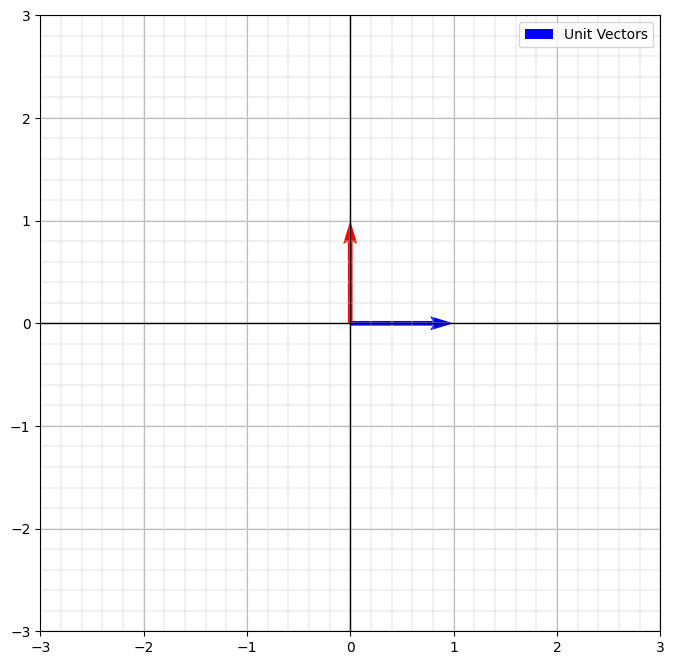

In [4]:
plt.figure(figsize=(8,8))
plt.quiver(i_hatOrigin, j_hatOrigin, i_hat, j_hat, color=['blue','red'], angles='xy', scale_units='xy',scale=1, label="Unit Vectors", alpha=1)
plt.plot(X, Y, color='lightgray', alpha=0.3)
plt.plot(X.T, Y.T, color='lightgray', alpha=0.3)
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.axhline(0,color="black", linewidth=1)
plt.axvline(0,color="black", linewidth=1)
plt.grid(True,alpha=1)
plt.legend()
plt.show()

**Define the matrix and show it's effect as a linear transformation**

The first one I will show is a rotation matrix, specifically [(0,1), (-1,0)] where each pair of parenthesis is a column

In [5]:
# Define all points as a matrix where each column is the vector for each point
X = X.ravel()
Y = Y.ravel()
v_old = np.vstack([X,Y])

# Define the rotation matrix
A = np.array([[0,1],[-1,0]]) # clockwise

#Multiply the matrices to get points after transformation
v_new = A @ v_old
i_new = A @ i_hat
j_new = A @ j_hat

Now that we have the 2xN matrix of the transformed points, we can convert v_new back into 31x31 matrix to graph

In [6]:
X = v_new[0,:].reshape(31,-1)
Y = v_new[1,:].reshape(31,-1)
u = [i_new[0],j_new[0]]
v = [i_new[1],j_new[1]]

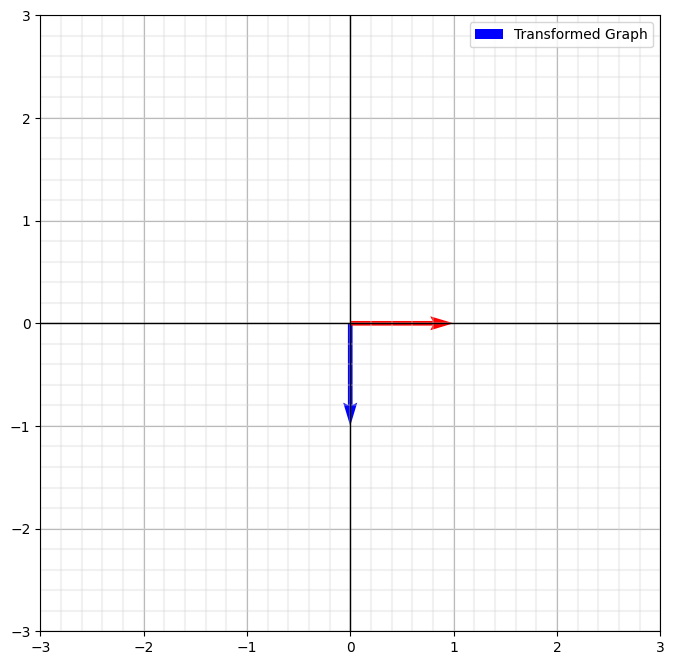

In [7]:
plt.figure(figsize=(8,8))
plt.plot(X, Y, color='lightgray', alpha=0.3)
plt.plot(X.T, Y.T, color='lightgray', alpha=0.3)
plt.quiver([0,0],[0,0],u,v,color=["blue","red"],angles='xy',scale_units='xy', scale=1,label='Transformed Graph', alpha=1)
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.axhline(0,color="black", linewidth=1)
plt.axvline(0,color="black", linewidth=1)
plt.grid(True,alpha=1)
plt.legend()
plt.show()

Now we do the same with the shear

In [8]:
#Define shear matrix
B = np.array([[1,1],[0,1]])

In [9]:
#Perform transformation
v_new = B @ v_old
i_new = B @ i_hat
j_new = B @ j_hat

#Convert back into points
X = v_new[0,:].reshape(31,-1)
Y = v_new[1,:].reshape(31,-1)
u = [i_new[0],j_new[0]]
v = [i_new[1],j_new[1]]

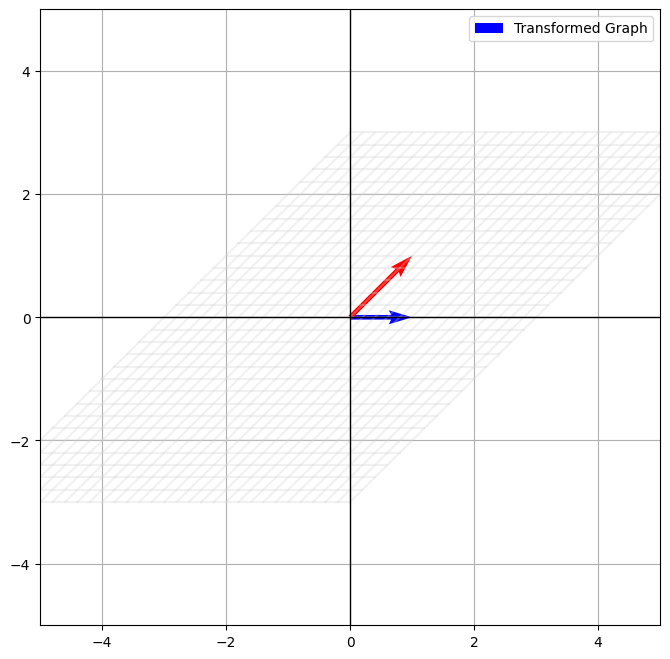

In [10]:
#Plot transformation
plt.figure(figsize=(8,8))
plt.plot(X, Y, color='lightgray', alpha=0.3)
plt.plot(X.T, Y.T, color='lightgray', alpha=0.3)
plt.quiver([0,0],[0,0],u,v,color=["blue","red"],angles='xy',scale_units='xy', scale=1,label='Transformed Graph', alpha=1)
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.axhline(0,color="black", linewidth=1)
plt.axvline(0,color="black", linewidth=1)
plt.grid(True,alpha=1)
plt.legend()
plt.show()

Pretty interesting to see how this one turned out! Grid lines stay parallel and the origin is fixed in linear transformations

**Now let's combine the transformations!**

In [11]:
C = A @ B @ A @ B @ A

In [12]:
#Perform transformation
v_new = C @ v_old
i_new = C @ i_hat
j_new = C @ j_hat

#Convert back into points
X = v_new[0,:].reshape(31,-1)
Y = v_new[1,:].reshape(31,-1)
u = [i_new[0],j_new[0]]
v = [i_new[1],j_new[1]]

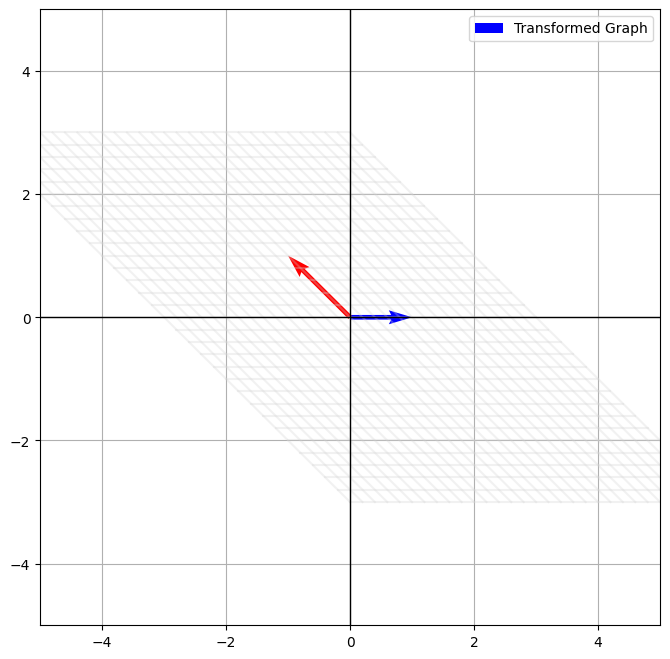

In [15]:
#Plot transformation
plt.figure(figsize=(8,8))
plt.plot(X, Y, color='lightgray', alpha=0.3)
plt.plot(X.T, Y.T, color='lightgray', alpha=0.3)
plt.quiver([0,0],[0,0],u,v,color=["blue","red"],angles='xy',scale_units='xy', scale=1,label='Transformed Graph', alpha=1)
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.axhline(0,color="black", linewidth=1)
plt.axvline(0,color="black", linewidth=1)
plt.grid(True,alpha=1)
plt.legend()
plt.show()